# Customer Churn Prediction

## Business Problem

A telecom company wants to predict whether a customer will leave the service.

This helps the company retain customers by identifying them before they churn.

In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded")

All libraries loaded


In [176]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ypyas\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [177]:
df = pd.read_csv(r"C:\Users\ypyas\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [178]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [179]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [180]:
df.shape

(7043, 21)

In [181]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [182]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [183]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [185]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [187]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [188]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [189]:
df[df['tenure']==0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [190]:
df.dropna(inplace=True)

In [191]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [192]:
df.duplicated().sum()

np.int64(0)

In [193]:
df.drop_duplicates(inplace=True)

In [194]:
df.duplicated().sum()

np.int64(0)

In [195]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [196]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

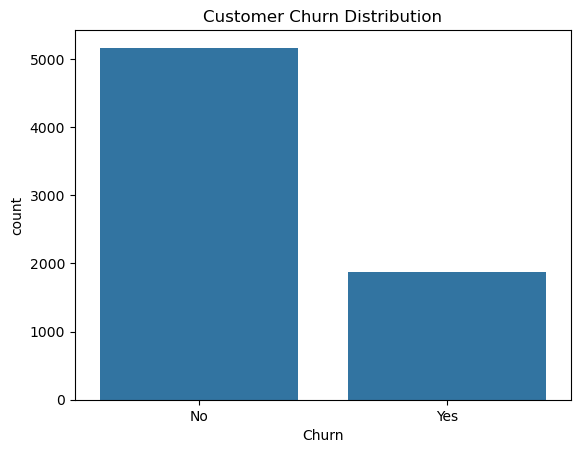

In [197]:
import seaborn as sns
sns.countplot(x='Churn', data = df)
plt.title('Customer Churn Distribution')
plt.show()

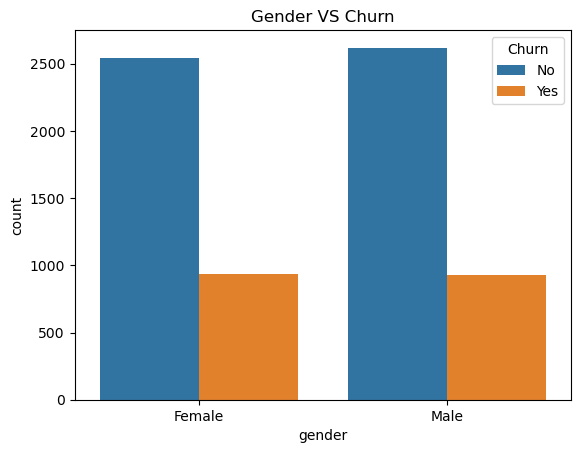

In [198]:
sns.countplot(data = df, x= 'gender', hue='Churn')
plt.title('Gender VS Churn')
plt.show()

In [199]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


### Observation

Customers with month-to-month contracts have the highest churn, while customers with one-year and two-year contracts show much lower churn.

### Business Insight

Long-term contracts improve customer retention because customers are committed for a longer period.

### Conclusion

Contract is an important feature for predicting customer churn.

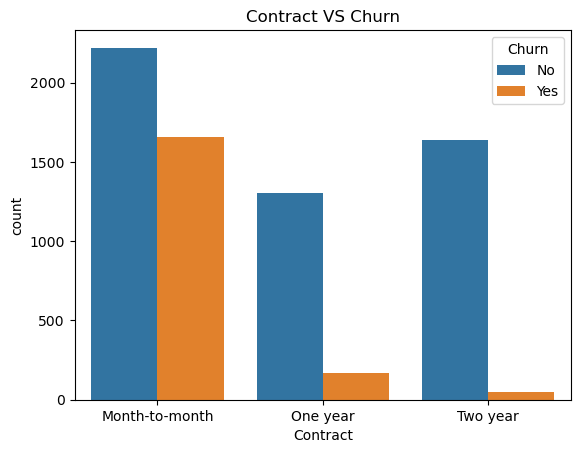

In [200]:
sns.countplot(data = df, x= 'Contract', hue='Churn')
plt.title('Contract VS Churn')
plt.show()

In [201]:
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


### Observation

Customers using Electronic Check have significantly higher churn compared to other payment methods.

### Business Insight

Electronic Check users appear to be at higher risk of leaving the company.

### Conclusion

Payment Method is an important feature for customer churn prediction.

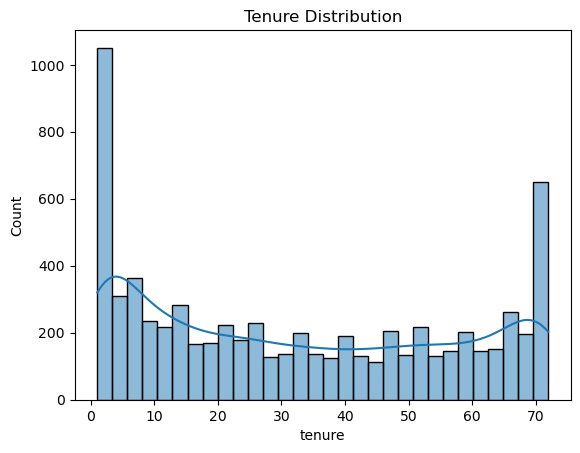

In [202]:
sns.histplot(df['tenure'], bins=30, kde= True)
plt.title('Tenure Distribution')
plt.show()

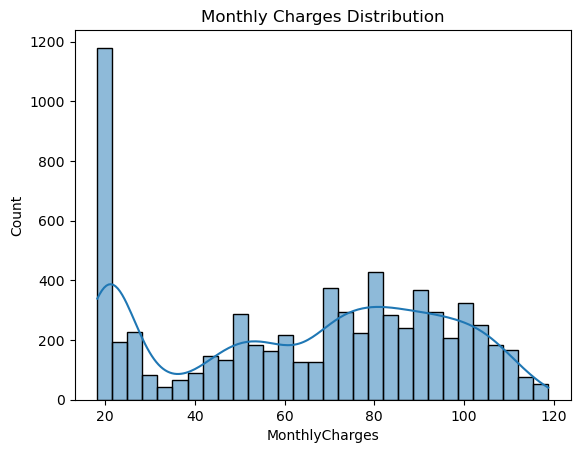

In [203]:
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

In [204]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


### Observation

Customers using Fiber Optic have significantly higher churn compared to other Internet Services methods.

### Business Insight

Fiber Optic users appear to be at higher risk of leaving the company.

### Conclusion

Internet Service is an important feature for customer churn prediction.

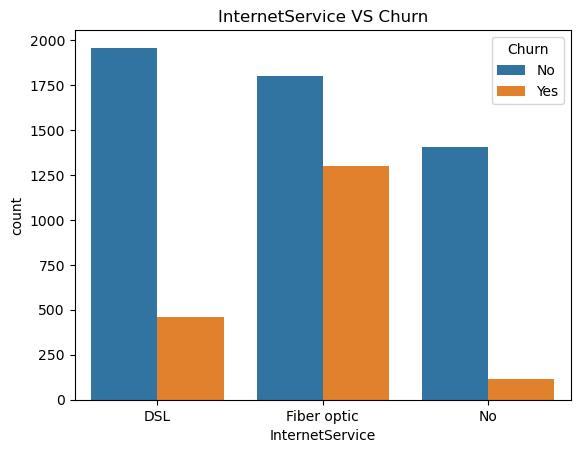

In [205]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title('InternetService VS Churn')
plt.show()

In [206]:
pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index')*100

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


### Observation

Customers without Online Security have the highest churn rate (41.65%), whereas customers with Online Security have a much lower churn rate (14.64%). Customers with no internet service show the lowest churn rate.

### Business Insight

Customers who do not use the Online Security service are much more likely to leave the company. Promoting or bundling Online Security plans may help improve customer retention.

### Recommendation

The company should encourage customers to subscribe to Online Security by providing discounts or promotional bundles.

### Conclusion

Online Security is one of the important features influencing customer churn and should be included in the predictive model.

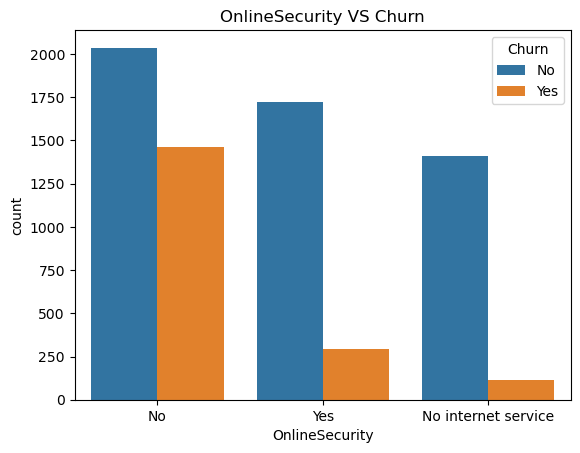

In [207]:
sns.countplot(data=df, x = 'OnlineSecurity', hue= 'Churn')
plt.title('OnlineSecurity VS Churn')
plt.show()

In [208]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index')*100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


### Observation

Customers without Tech Support have the highest churn rate (41.51%), whereas customers with Tech Support and no tech Support show the lowest churn rate.

### Business Insight

Customers who do not use the Tech Support service are much more likely to leave the company.

### Conclusion

Tech Support is one of the important features influencing customer churn and should be included in the predictive model.

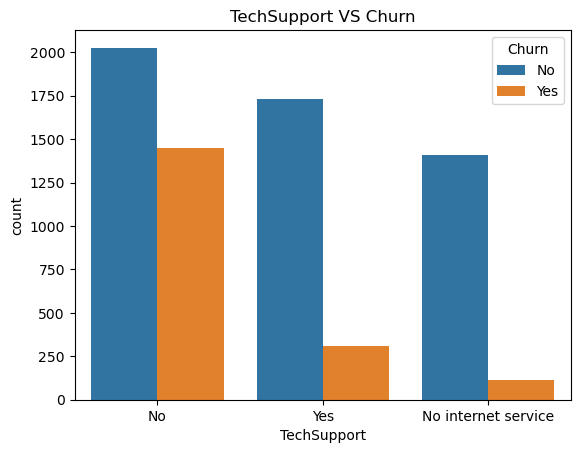

In [209]:
sns.countplot(data=df, x = 'TechSupport', hue= 'Churn')
plt.title('TechSupport VS Churn')
plt.show()

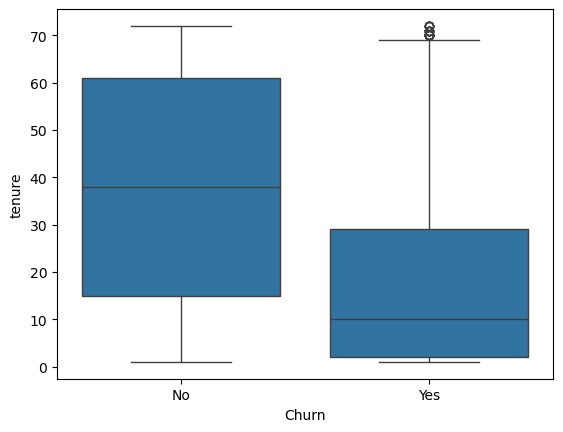

In [210]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

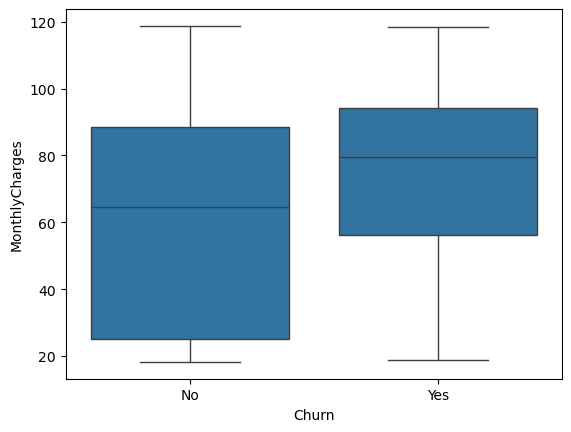

In [211]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

In [212]:
df.drop('customerID',axis=1, inplace=True)

In [213]:
binary = ['gender','Partner','Dependents','PhoneService','PaperlessBilling', 'SeniorCitizen','Churn']
multi = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

In [214]:
le = LabelEncoder()

for i in binary:
    df[i] = le.fit_transform(df[i])

In [215]:
df = pd.get_dummies(df, columns = multi, drop_first = True)

In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   bool   
 11  MultipleL

In [217]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [218]:
bool_col = df.select_dtypes('bool').columns
df[bool_col] = df[bool_col].astype(int)

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleL

In [220]:
x = df.drop('Churn',axis=1)
y = df['Churn']

In [221]:
x_train, x_test, y_train, y_test = train_test_split(x,y , test_size=0.2, stratify = y, random_state=42)

In [222]:
x_train.shape

(5625, 30)

In [223]:
x_test.shape

(1407, 30)

In [224]:
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [225]:
model = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [226]:
y_pred = model.predict(x_test)

In [227]:
acc = accuracy_score(y_test, y_pred)
acc

0.7263681592039801

In [228]:
mat = confusion_matrix(y_test, y_pred)
mat

array([[724, 309],
       [ 76, 298]])

In [229]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [230]:
y_prob = model.predict_proba(x_test)[:,1]
roc_auc_score(y_test, y_prob)


0.8349765233911922

In [231]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

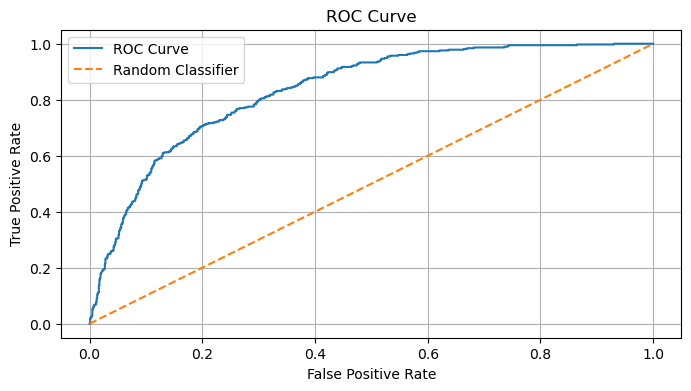

In [232]:
plt.figure(figsize=(8,4))
plt.plot(fpr, tpr, label = 'ROC Curve')
plt.plot([0,1],[0,1], linestyle='--', label = 'Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [233]:
precision, recall, threshold = precision_recall_curve(y_test, y_prob)
average_precision_score(y_test, y_prob)

0.6173485194929599

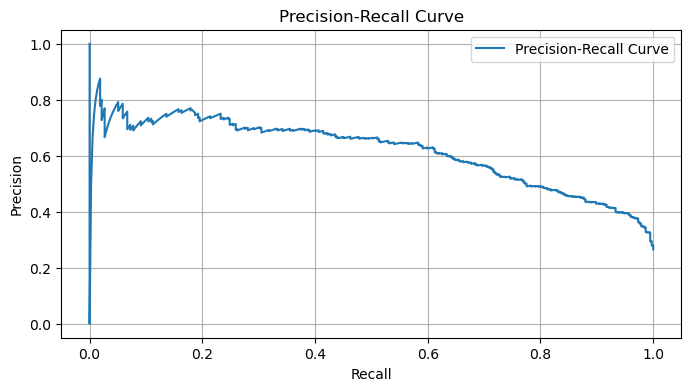

In [234]:
plt.figure(figsize=(8,4))
plt.plot(recall,precision, label = 'Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [235]:
score = cross_val_score(model, x,y, cv=5, scoring='roc_auc')

print('score:',score)
print('score mean:',score.mean())

score: [0.85769085 0.85902128 0.8347573  0.83593718 0.83903329]
score mean: 0.8452879796879618


In [236]:
param_grid = {'C':[0.01,0.1,1,10,100], 'penalty':['l1', 'l2'], 'solver':['liblinear']}

grid = GridSearchCV(estimator = LogisticRegression(max_iter=5000), param_grid = param_grid, scoring = 'roc_auc', cv= 5, n_jobs=-1)

grid.fit(x_train, y_train)

,estimator,LogisticRegre...max_iter=5000)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [237]:
print('Best parameter:',grid.best_params_)
print('Best score:',grid.best_score_)

Best parameter: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best score: 0.8462376606444403


In [238]:
best_model = grid.best_estimator_
print('best estimator:', best_model)

best estimator: LogisticRegression(C=10, max_iter=5000, solver='liblinear')


In [239]:
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:,1]

In [240]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8002842928216063


In [241]:
print("ROC-AUC:",roc_auc_score(y_test,y_prob))

ROC-AUC: 0.8351240610650668


In [242]:
print(confusion_matrix(y_test,y_pred))

[[912 121]
 [160 214]]


In [243]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.74      1407
weighted avg       0.79      0.80      0.80      1407



In [244]:
best_model.coef_

array([[-0.01067321,  0.07149411, -0.01346103, -0.10480153, -1.40374167,
         0.09971246,  0.14216182, -2.00483195,  0.69738552, -0.09971246,
         0.30818269,  1.19788229, -0.14429737, -0.14429737, -0.05188228,
        -0.14429737,  0.05952714, -0.14429737,  0.15853118, -0.14429737,
        -0.03181376, -0.14429737,  0.43362745, -0.14429737,  0.42097026,
        -0.31049707, -0.60446222,  0.01848838,  0.18240278,  0.03323773]])

In [245]:
feature_imp = pd.DataFrame({'Feature': x.columns, 'Coefficient':best_model.coef_[0]})
feature_imp

,Feature,Coefficient
0,gender,-0.010673
1,SeniorCitizen,0.071494
2,Partner,-0.013461
3,Dependents,-0.104802
4,tenure,-1.403742
5,PhoneService,0.099712
6,PaperlessBilling,0.142162
7,MonthlyCharges,-2.004832
8,TotalCharges,0.697386
9,MultipleLines_No phone service,-0.099712


In [246]:
feature_imp.sort_values(by='Coefficient',ascending=False)

,Feature,Coefficient
11,InternetService_Fiber optic,1.197882
8,TotalCharges,0.697386
22,StreamingTV_Yes,0.433627
24,StreamingMovies_Yes,0.420970
10,MultipleLines_Yes,0.308183
28,PaymentMethod_Electronic check,0.182403
18,DeviceProtection_Yes,0.158531
6,PaperlessBilling,0.142162
5,PhoneService,0.099712
1,SeniorCitizen,0.071494


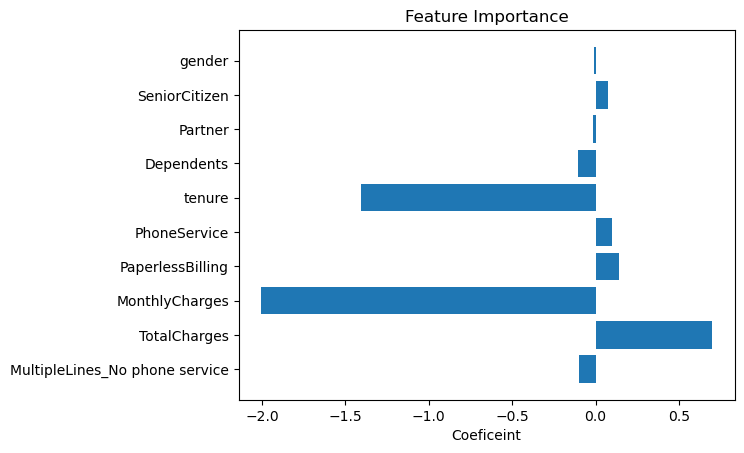

In [247]:
# feature_imp.plot(x='Feature', y='Coefficient', kind='barh', figsize=(10,8))
top10 = feature_imp.head(10)
plt.barh(top10['Feature'], top10['Coefficient'])
plt.gca().invert_yaxis()
plt.xlabel('Coeficeint')
plt.title('Feature Importance')
plt.show()

In [248]:
df[['MonthlyCharges','TotalCharges','tenure']].corr()

,MonthlyCharges,TotalCharges,tenure
MonthlyCharges,1.000000,0.651065,0.246862
TotalCharges,0.651065,1.000000,0.825880
tenure,0.246862,0.825880,1.000000


In [249]:
# *************************************************************************************************************************
# *************************************************************************************************************************
# *************************************************************************************************************************
# *************************************************************************************************************************
# *************************************************************************************************************************

In [250]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [251]:
y_pred = model.predict(x_test)

In [252]:
acc = accuracy_score(y_test, y_pred)
print('Accuracy:', acc)

Accuracy: 0.7782515991471215


In [253]:
con_mat = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:','\n',con_mat)

Confusion Matrix: 
 [[872 161]
 [151 223]]


In [254]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [255]:
print("Train Accuracy:", model.score(x_train, y_train))
print("Test Accuracy:", model.score(x_test, y_test))

Train Accuracy: 0.8014222222222223
Test Accuracy: 0.7782515991471215


In [256]:
y_prob = model.predict_proba(x_test)[:,1]

roc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC score:", roc_score)

ROC-AUC score: 0.8191524607730973


In [257]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

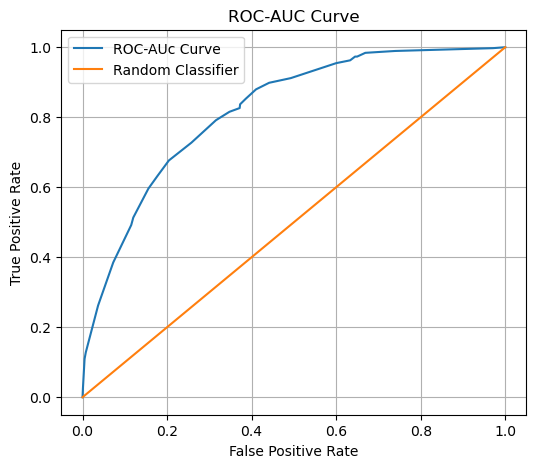

In [258]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC-AUc Curve')
plt.plot([0,1],[0,1], label ='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [259]:
precision, recall, threshold = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
print('Average Precision Score:', ap)

Average Precision Score: 0.6014764555221164


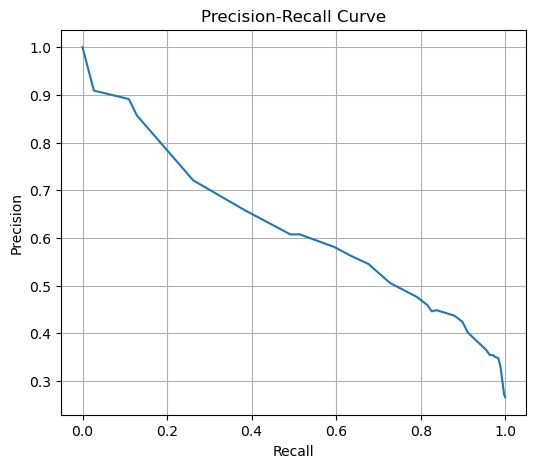

In [260]:
plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

In [261]:
cross_score = cross_val_score(model, x, y, cv=5, scoring='roc_auc')
print('cross Validation Score:', cross_score)
print('Cross Validation Mean:',cross_score.mean())

cross Validation Score: [0.83629919 0.83881509 0.8115214  0.80994409 0.82459038]
Cross Validation Mean: 0.824234029693925


In [262]:
param_grid = {'criterion':['gini', 'entropy'], 'max_depth':[3,5,7,10], 'min_samples_split':[2,5,10], 'min_samples_leaf':[1,2,5]}

In [263]:
grid = GridSearchCV(estimator= DecisionTreeClassifier(random_state=42), param_grid = param_grid, scoring='roc_auc', cv=5, n_jobs=-1)

grid.fit(x_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [264]:
print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best ROC-AUC: 0.827259144687295


In [265]:
best_model = grid.best_estimator_
print('Best Model:',best_model)

Best Model: DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, random_state=42)


In [266]:
best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:,1]

In [267]:
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.7782515991471215


In [268]:
print(confusion_matrix(y_test, y_pred))


[[872 161]
 [151 223]]


In [269]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [270]:
importance = best_model.feature_importances_
importance

array([0.        , 0.00694396, 0.        , 0.        , 0.44241249,
       0.00760569, 0.        , 0.02428229, 0.03349666, 0.        ,
       0.01015994, 0.33969322, 0.        , 0.        , 0.01517703,
       0.01544111, 0.00909045, 0.        , 0.        , 0.        ,
       0.01219052, 0.        , 0.        , 0.0268466 , 0.        ,
       0.00913461, 0.020648  , 0.        , 0.02687742, 0.        ])

In [271]:
importance = pd.DataFrame({'Feature': x.columns, 'Importance':best_model.feature_importances_})

importance = importance.sort_values(by='Importance', ascending=False)

importance.head(10)

,Feature,Importance
4,tenure,0.442412
11,InternetService_Fiber optic,0.339693
8,TotalCharges,0.033497
28,PaymentMethod_Electronic check,0.026877
23,StreamingMovies_No internet service,0.026847
7,MonthlyCharges,0.024282
26,Contract_Two year,0.020648
15,OnlineBackup_No internet service,0.015441
14,OnlineSecurity_Yes,0.015177
20,TechSupport_Yes,0.012191


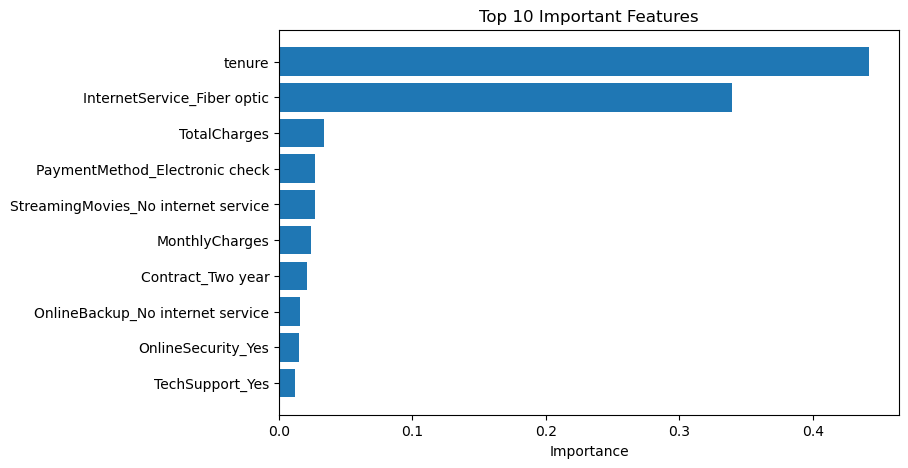

In [272]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top10['Feature'],
         top10['Importance'])

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.show()

In [273]:
# ********************************************************************************************************************
# ********************************************************************************************************************
# ********************************************************************************************************************
# ********************************************************************************************************************

In [274]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(max_depth=5, random_state=42)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [275]:
y_pred = model.predict(x_test)

In [276]:
acc = accuracy_score(y_test, y_pred)
print('Accuracy:', acc)

Accuracy: 0.7867803837953091


In [277]:
con_mat = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:', '\n',con_mat)

Confusion Matrix: 
 [[955  78]
 [222 152]]


In [278]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1033
           1       0.66      0.41      0.50       374

    accuracy                           0.79      1407
   macro avg       0.74      0.67      0.68      1407
weighted avg       0.77      0.79      0.77      1407



In [279]:
y_prob = model.predict_proba(x_test)[:,1]

roc_score = roc_auc_score(y_test, y_prob)
print('ROC AUC Score:', roc_score)

ROC AUC Score: 0.8362927147449669


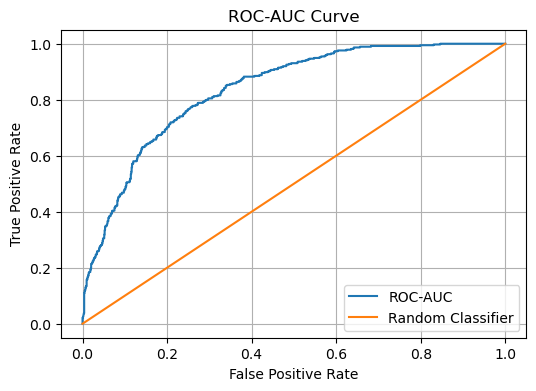

In [280]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='ROC-AUC')
plt.plot([0,1],[0,1], label ='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.grid(True)
plt.show()

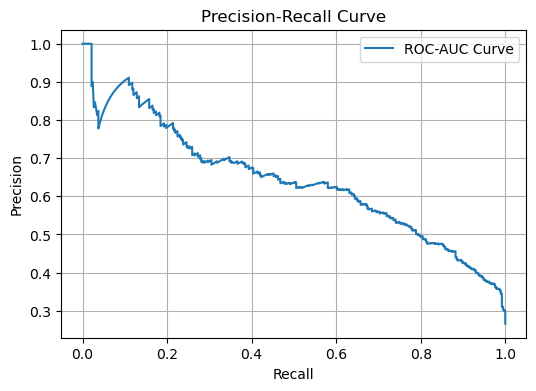

In [281]:
precision, recall, threshold = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, label='ROC-AUC Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [282]:
score = cross_val_score(model, x, y, cv=5, scoring='roc_auc')
print('Validation Score:', score)
print('Validation Score Mena:', score.mean())

Validation Score: [0.8576585  0.85285964 0.83393199 0.83225034 0.83939213]
Validation Score Mena: 0.8432185193562042


In [283]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

In [284]:
grid = GridSearchCV(estimator= RandomForestClassifier(random_state=42), param_grid = param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

grid.fit(x_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [285]:
print("Best Parameters:",grid.best_params_)

print("Best ROC-AUC:",grid.best_score_)

Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}
Best ROC-AUC: 0.8460481670135318


In [286]:
best_model = grid.best_estimator_

In [287]:
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:,1]

In [288]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7945984363894811


In [289]:
print(confusion_matrix(y_test, y_pred))

[[934  99]
 [190 184]]


In [290]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [291]:
importance = best_model.feature_importances_
importance

array([0.01073577, 0.01098714, 0.01186459, 0.01214215, 0.18566794,
       0.00282102, 0.01885087, 0.09508912, 0.1577115 , 0.00360537,
       0.01369039, 0.07280702, 0.01382041, 0.01480434, 0.03668303,
       0.01186831, 0.01825033, 0.01229803, 0.01002906, 0.0123715 ,
       0.02801153, 0.01632782, 0.01026251, 0.01644201, 0.0103466 ,
       0.03849124, 0.07209944, 0.00868239, 0.06678924, 0.00644932])

In [292]:
importance = pd.DataFrame({'Feature':x.columns, 'Importance':best_model.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)

print(importance.head(10))

                           Feature  Importance
4                           tenure    0.185668
8                     TotalCharges    0.157712
7                   MonthlyCharges    0.095089
11     InternetService_Fiber optic    0.072807
26               Contract_Two year    0.072099
28  PaymentMethod_Electronic check    0.066789
25               Contract_One year    0.038491
14              OnlineSecurity_Yes    0.036683
20                 TechSupport_Yes    0.028012
6                 PaperlessBilling    0.018851


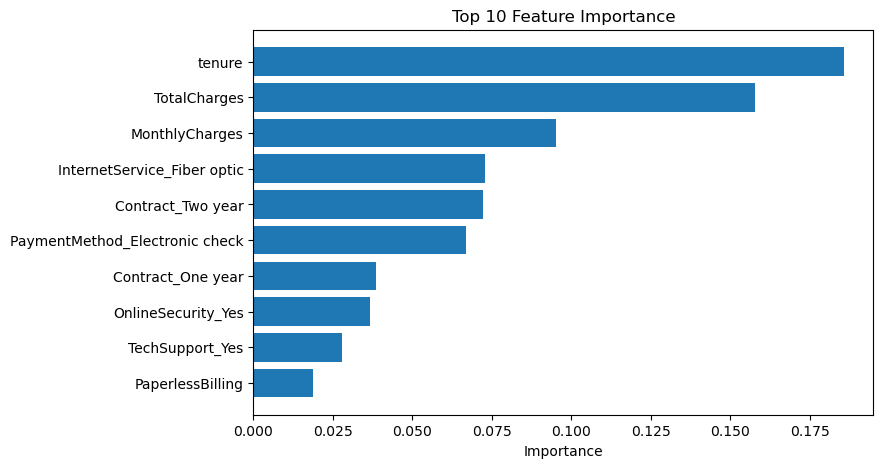

In [293]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importance")
plt.show()

In [294]:
# *******************************************************************************************************************
# *******************************************************************************************************************
# *******************************************************************************************************************
# *******************************************************************************************************************

In [316]:
# conda install -c conda-forge xgboost

In [296]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric='logloss')
model.fit(x_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [297]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]

In [298]:
print('Accuracy:',accuracy_score(y_test, y_pred))

Accuracy: 0.7953091684434968


In [299]:
print('Confusion matrix:', '\n',confusion_matrix(y_test, y_pred))

Confusion matrix: 
 [[919 114]
 [174 200]]


In [300]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [301]:
roc_score = roc_auc_score(y_test, y_prob)
print('Roc Auc score:', roc_score)

Roc Auc score: 0.8403823555295568


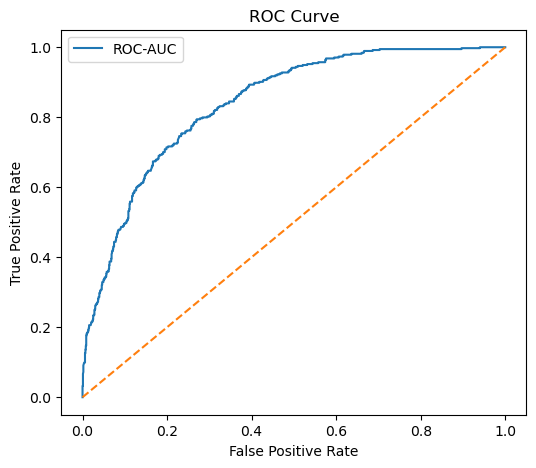

In [302]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC-AUC')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Average Precision: 0.6574651133376245


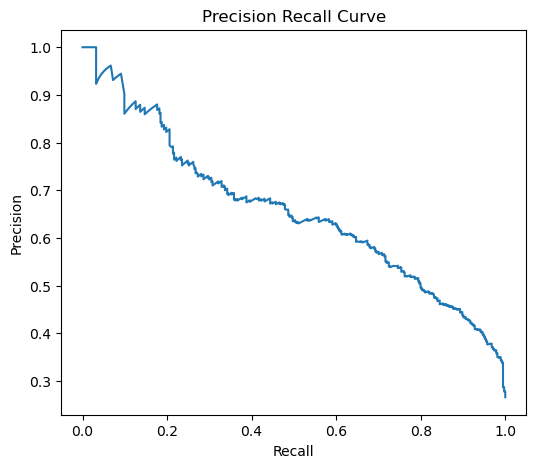

In [303]:
precision, recall, threshold = precision_recall_curve(y_test, y_prob)

ap = average_precision_score(y_test, y_prob)
print("Average Precision:", ap)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()

In [304]:
score = cross_val_score(model, x, y, scoring='roc_auc', cv=5)
print('Validation Score:', score)
print('Validation Score Mean:', score.mean())

Validation Score: [0.85902775 0.85668268 0.83415648 0.84130679 0.84370466]
Validation Score Mean: 0.8469756733303957


In [305]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [306]:
grid = GridSearchCV(estimator= XGBClassifier(random_state=42), param_grid = param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

grid.fit(x_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [307]:
print("Best Parameters:",grid.best_params_)

print("Best ROC-AUC:",grid.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best ROC-AUC: 0.8482083134257046


In [308]:
best_model = grid.best_estimator_

In [309]:
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:,1]

In [310]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7931769722814499


In [311]:
print(confusion_matrix(y_test, y_pred))

[[922 111]
 [180 194]]


In [312]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [313]:
best_model.feature_importances_

array([0.00945249, 0.01323347, 0.00793546, 0.01531465, 0.05859363,
       0.01720851, 0.02104706, 0.02260114, 0.01157427, 0.02041   ,
       0.01213145, 0.1239421 , 0.08023416, 0.03333241, 0.0302241 ,
       0.        , 0.01235437, 0.        , 0.01080409, 0.        ,
       0.01721114, 0.        , 0.01540869, 0.        , 0.02498416,
       0.12355131, 0.20308624, 0.00669012, 0.1014728 , 0.0072022 ],
      dtype=float32)

In [314]:
importance = pd.DataFrame({'Feature':x.columns, 'Importance':model.feature_importances_})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance.head(10))

                           Feature  Importance
11     InternetService_Fiber optic    0.197150
26               Contract_Two year    0.197105
25               Contract_One year    0.186823
12              InternetService_No    0.078498
4                           tenure    0.065074
28  PaymentMethod_Electronic check    0.046343
24             StreamingMovies_Yes    0.031468
14              OnlineSecurity_Yes    0.026183
6                 PaperlessBilling    0.025557
22                 StreamingTV_Yes    0.020811


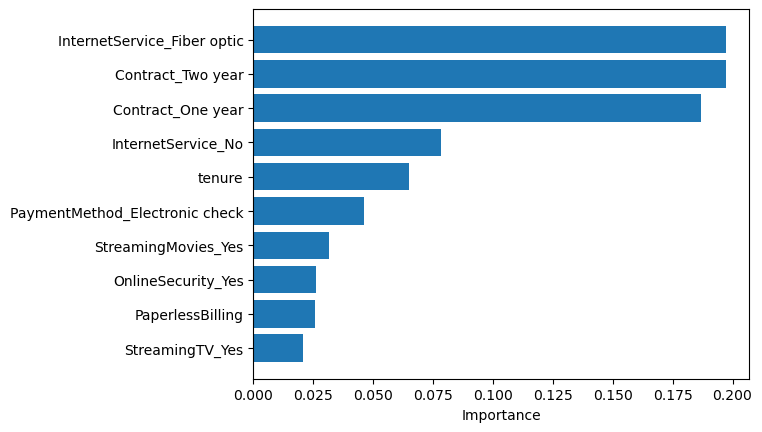

In [315]:
top10 = importance.head(10)

plt.barh(top10['Feature'], top10['Importance'])
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()